# Pyplops Kirchhoff - моделирование и миграция с помощью линейного оператора из библиотеки PyLops

В этом ноутбуке мы познакомимся немного с библиотекой для создания линейных операторов **PyLops** на примере **оператора Кирхгофа** в библиотеке **Pylops**. 
План работы:
1) Создадим модель отражательной способности (reflectivity).
2) Сделаем синтетику с помощью forarwad-режима оператора Кирхгофа
3) По полученной сейсмограмме создадим миграцию в adjoint-режиме оператора.

In [ ]:
# Установка библиотеки PyLops (если не установлена)
#!pip install pylops

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pylops.waveeqprocessing import Kirchhoff
from pylops.utils.wavelets import ricker

import warnings
warnings.filterwarnings('ignore')

## 1.Создание модели
Возьмём нашу двухслойную модель из прошлого ноутбука и сделаем из неё **reflectivity** (отражательную способность - ведь именно к ней применяется оператор Кирхгофа в режиме моделирования). 

Только дифрактор сдвинем вправо, чтоб годографы были разнесены с рефлектором - для наглядности. А среду для распространения для упрощения эксперимента возьмем **константную с V=2000 м/с**.

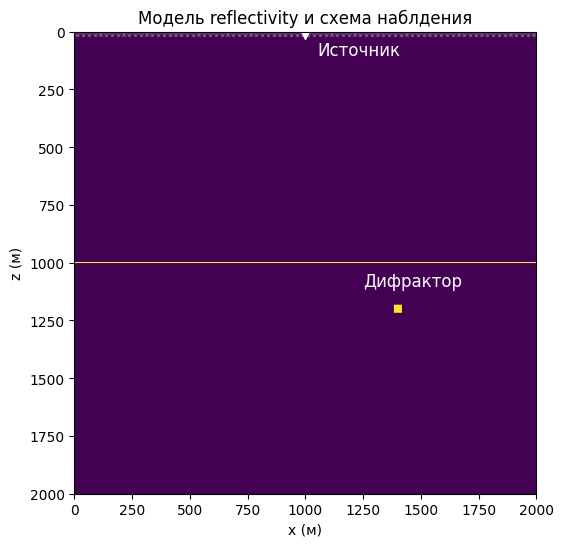

In [2]:
# Параметры модели
nx = 401
nz = 401
dx = 5
dz = 5
x = np.arange(nx) * dx
z = np.arange(nz) * dz

z_boundary = 1000.0
iboundary = int(z_boundary / dz)
refl = np.zeros((nz, nx)) 
refl[iboundary, :] = 1.0 

# добавим дифрактор
diffractor_x = int(nx * 0.7)
diffractor_z = int(nz * 0.6)
difw = 3 # ширина дифрактора
refl[diffractor_z - difw:diffractor_z+difw+1, diffractor_x-difw:diffractor_x+difw+1] = 1.0

# Параметры источника
sx_idx = nx // 2
sz_idx = 0
sx = x[sx_idx]
sz = z[sz_idx]

# Параметры приемников - через каждые 5 точек сетки (25 м)
rx_idx = np.arange(0, nx + 1, 5, dtype=int)
rz_idx = np.zeros(len(rx_idx), dtype=int) 
rx = x[rx_idx]
rz = z[rz_idx]

vconst = 2000.0


plt.figure(figsize=(6, 6))
plt.imshow(refl, extent=[x.min(), x.max(), z.max(), z.min()], cmap='viridis')
plt.scatter(sx, sz, color='white', s=100, marker='v')
plt.scatter(rx, rz, color='white', s=40, alpha=0.2, marker='x')
plt.text(x[sx_idx]+50, z[sz_idx]+100, 'Источник', color='white', fontsize=12)
plt.text(x[diffractor_x]-150, z[diffractor_z]-100, f'Дифрактор', color='white', fontsize=12)
plt.title("Модель reflectivity и схема наблдения")
plt.xlabel("x (м)")
plt.ylabel("z (м)")
plt.show()

## 2. Создание оси времени и вэйвлета

In [3]:
# Временная ось (сек)
dt = 0.002  # 2 мс
tmax = 2.5  # 2.5 с, достаточно для двукратного пробега до 2 км
nt = int(tmax / dt) + 1
t = np.arange(nt) * dt

# Риккеровский вэйвлет
f0 = 20.0  # Гц
wav, tw, wawc = ricker(t[:41], f0)  # короткий вэйвлет; подадим отдельно, центр возьмем по максимуму


## 3. Создание линейного оператора с помощью PyLops
Создадим оператор Кирхгофа для константной скорости. 

Для более сложных моделей можно задать ```mode='eikonal'```. Для этого нужно будет дополнительно установить библиотеку ```scikit-fmm```, которую **PyLops** использует для расчета времен пробега волны по методу fast marching. 

Параметр ```dynamic=True``` включает дополнительный амплитудный член в расчет, что даёт корректную обработку апмлитуд. Если интересует только кинематика, можно оставить ```dynamic=False```.

In [4]:
# Геометрия источника и приемников для оператора

srcs = np.array([[sx], [sz]], dtype=float)           # (2, nsrcs)
recs = np.vstack([rx, rz]).astype(float)             # (2, nrecs)

nsrcs = srcs.shape[1]
nrecs = recs.shape[1]
print(f"nsrcs={nsrcs}, nrecs={nrecs}, nt={nt}")

# Создаем оператор Кирхгофа
K = Kirchhoff(
    z=z, x=x, t=t,
    srcs=srcs, recs=recs,
    vel=vconst,
    wav=wav, wavcenter=wawc,
    mode='analytic',
    wavfilter=True,
    angleaperture=30.0,
    dynamic=False,
    engine='numpy', dtype='float64', name='K')


nsrcs=1, nrecs=81, nt=1251


## 4. Применение прямого оператора для получения синтетической сейсмограммы

Применяем полученный оператор к модели reflectivity

In [5]:
# Для применения оператора Кирхгофа нужно векторизовать модель. Порядок "F" означает, что массив будет считан по столбцам.
mvec = refl.ravel(order="F")
dvec = K @ mvec  # размер (nt * nrecs * nsrcs,)

# Преобразуем в (nt, nrecs, nsrcs)
d = dvec.reshape(nt, nrecs, nsrcs, order='F')
seismogram = d[:, :, 0]

Визуализация результата 

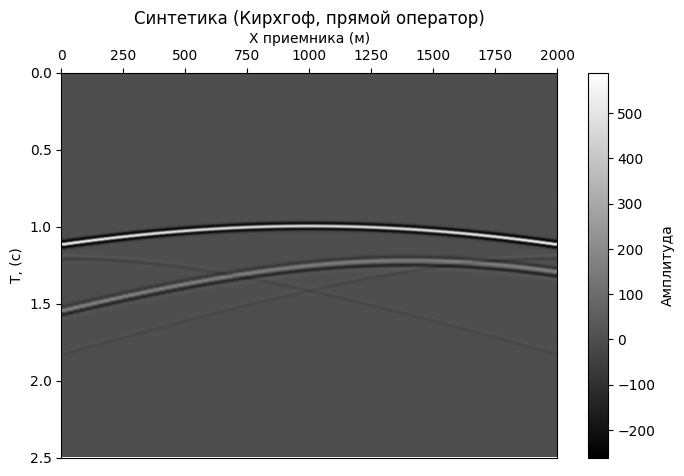

In [6]:
plt.figure(figsize=(8, 5))
im = plt.imshow(seismogram, aspect='auto', cmap='gray', extent=[rx.min(), rx.max(), t.max(), t.min()])

# Получаем текущую ось
ax = plt.gca()

# Переносим ось X наверх
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

# Устанавливаем подписи
plt.title('Синтетика (Кирхгоф, прямой оператор)')
plt.xlabel('X приемника (м)')
plt.ylabel('T, (с)')
plt.colorbar(im, label='Амплитуда')

plt.show()

## 5. Применение сопряженного оператора для получения миграции

Применяем наш **оператор Кирхгофа** к сейсмограмме

In [7]:
# Аналогично, векторизуем сейсмограмму и применяем сопряженный оператор
seisvec = seismogram.ravel(order='F')

migration = K.H @ seisvec

migration = migration.reshape(refl.shape, order='F')

Сравнительная визуализация: reflectivity vs миграция

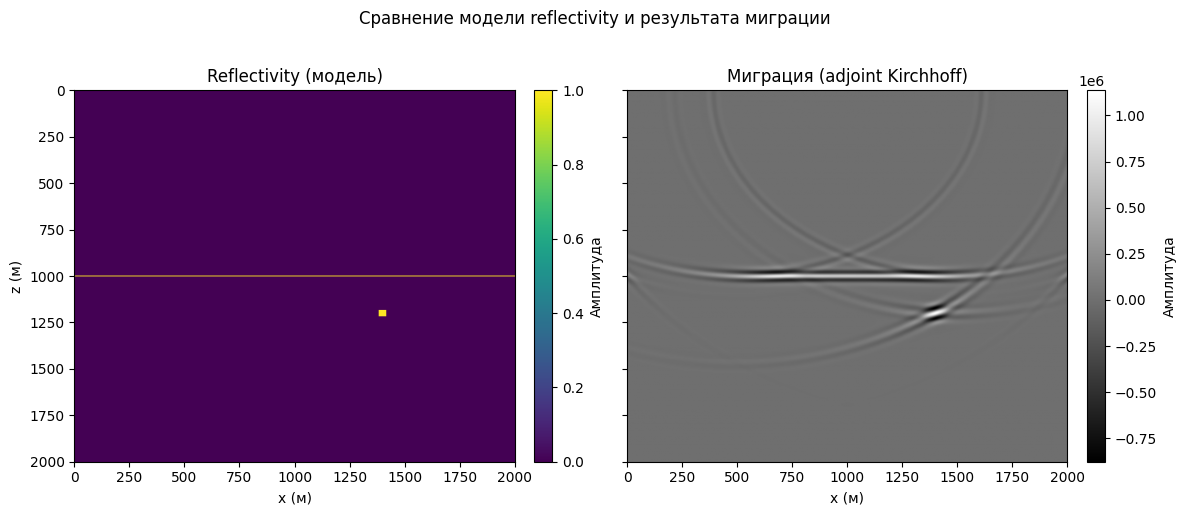

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Reflectivity
im0 = axes[0].imshow(
    refl,
    extent=[x.min(), x.max(), z.max(), z.min()],
    cmap='viridis',
    aspect='auto'
)
axes[0].set_title('Reflectivity (модель)')
axes[0].set_xlabel('x (м)')
axes[0].set_ylabel('z (м)')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='Амплитуда')

# Migration

im1 = axes[1].imshow(
    migration,
    extent=[x.min(), x.max(), z.max(), z.min()],
    cmap='gray',   
    aspect='auto'
)
axes[1].set_title('Миграция (adjoint Kirchhoff)')
axes[1].set_xlabel('x (м)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Амплитуда')

plt.suptitle('Сравнение модели reflectivity и результата миграции', y=1.02)
plt.tight_layout()
plt.show()


Вот и всё, вот так просто. Никаких формул, циклов, матриц и т.п.
Рекомендую ознакомиться с другими возможносями библиотеки **PyLops**, у них есть замечательные обучающие примеры:


https://pylops.readthedocs.io/en/stable/tutorials/index.html